# Fase 4 CRISP-DM — Modeling: Segmentación RFM de Clientes
**Proyecto:** Customer Behavior Analysis — Olist Brazilian E-Commerce  
**Objetivo:** Segmentar la base de clientes usando el modelo RFM (Recency, Frequency, Monetary)  
para identificar grupos accionables: Champions, Loyal, At Risk, Lost y New Customers.

**¿Por qué RFM?** Es el framework estándar de segmentación en e-commerce: interpretable,  
basado en comportamiento real y directamente accionable por equipos de marketing y retención.

**Fuente de datos:** `data/olist_master.csv` (Fase 3)

---

## 0. Imports y configuración

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path().resolve().parent
CSV  = ROOT / "data" / "olist_master.csv"
DASH = ROOT / "dashboard"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.2f}".format)

print(f"CSV: {CSV}  →  existe: {CSV.exists()}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



CSV: C:\Users\pardo\Documents\portfolio\proyecto 1\data\olist_master.csv  →  existe: True


---
## 1. Carga de datos y fecha de referencia
La fecha de referencia (`snapshot_date`) es el día siguiente al último pedido del dataset.  
Esto simula el punto de vista de un analista que ejecuta el análisis al cierre del período.

In [2]:
df = pd.read_csv(CSV, parse_dates=["order_purchase_timestamp"])

# Fecha de referencia: un día después del último pedido
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

print(f"Pedidos cargados:  {len(df):,}")
print(f"Clientes únicos:   {df['customer_unique_id'].nunique():,}")
print(f"Primer pedido:     {df['order_purchase_timestamp'].min().date()}")
print(f"Último pedido:     {df['order_purchase_timestamp'].max().date()}")
print(f"Snapshot date:     {snapshot_date.date()}")

Pedidos cargados:  96,457
Clientes únicos:   93,337
Primer pedido:     2016-09-15
Último pedido:     2018-08-29
Snapshot date:     2018-08-30


---
## 2. Cálculo de métricas RFM
Para cada `customer_unique_id` calculamos:

| Métrica | Definición | Interpretación |
|---------|-----------|----------------|
| **R** (Recency) | Días desde la última compra hasta `snapshot_date` | Menor = más reciente = mejor |
| **F** (Frequency) | Número de pedidos únicos | Mayor = más leal = mejor |
| **M** (Monetary) | Suma de `price_total` de todos sus pedidos | Mayor = más valioso = mejor |

In [3]:
rfm = (
    df.groupby("customer_unique_id", as_index=False)
    .agg(
        last_purchase  =("order_purchase_timestamp", "max"),
        frequency      =("order_id",                 "nunique"),
        monetary       =("price_total",               "sum"),
    )
)

# Recency: días desde la última compra hasta snapshot_date
rfm["recency"] = (snapshot_date - rfm["last_purchase"]).dt.days
rfm = rfm.drop(columns="last_purchase")

print(f"Clientes en tabla RFM: {len(rfm):,}")
print(f"\nDistribución de Frequency:")
print(rfm["frequency"].value_counts().sort_index().head(8).to_string())
print(f"\nEstadísticas RFM:")
display(rfm[["recency", "frequency", "monetary"]].describe().round(1))

Clientes en tabla RFM: 93,337

Distribución de Frequency:
frequency
1    90536
2     2573
3      181
4       28
5        9
6        5
7        3
9        1

Estadísticas RFM:


,recency,frequency,monetary
count,93337.00,93337.00,93337.00
mean,237.90,1.00,141.60
std,152.60,0.20,215.70
min,1.00,1.00,0.80
25%,114.00,1.00,47.60
50%,219.00,1.00,89.70
75%,346.00,1.00,154.70
max,714.00,15.00,13440.00


---
## 3. Scoring por quintiles (escala 1–5)
Dividimos cada métrica en 5 grupos iguales (quintiles) y asignamos un score de 1 a 5:
- **R_score:** 5 = más reciente (menor recency), 1 = menos reciente
- **F_score:** 5 = más frecuente, 1 = menos frecuente  
- **M_score:** 5 = mayor gasto, 1 = menor gasto

**Nota técnica:** Frequency tiene muy poca varianza (>96% de clientes con 1 solo pedido).  
Usamos `rank(method='first')` para desempatar antes del quintil.

In [4]:
def quintile_score(series: pd.Series, ascending: bool = True) -> pd.Series:
    """Asigna score 1-5 por quintiles. ascending=True → valor alto = score alto."""
    ranked = series.rank(method="first", ascending=ascending)
    return pd.qcut(ranked, q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# R: recency inversa (menor días = más reciente = mejor = score 5)
rfm["R_score"] = quintile_score(rfm["recency"],   ascending=False)  # invertido
rfm["F_score"] = quintile_score(rfm["frequency"], ascending=True)
rfm["M_score"] = quintile_score(rfm["monetary"],  ascending=True)

# Score compuesto: media de los tres scores (escala 1-5)
rfm["RFM_score"] = (rfm[["R_score", "F_score", "M_score"]].mean(axis=1)).round(2)

# String concatenado para lookup de segmento
rfm["RFM_string"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

print("Distribución de R_score:")
print(rfm["R_score"].value_counts().sort_index().to_string())
print("\nDistribución de F_score:")
print(rfm["F_score"].value_counts().sort_index().to_string())
print("\nPrimeras filas:")
display(rfm.head(5))

Distribución de R_score:
R_score
1    18668
2    18667
3    18667
4    18667
5    18668

Distribución de F_score:
F_score
1    18668
2    18667
3    18667
4    18667
5    18668

Primeras filas:


,customer_unique_id,frequency,monetary,recency,R_score,F_score,M_score,RFM_score,RFM_string
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,112,4,1,4,3.00,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,115,4,1,1,2.00,411
2,0000f46a3911fa3c0805444483337064,1,69.00,537,1,1,2,1.33,112
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,321,2,1,1,1.33,211
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,288,2,1,5,2.67,215


---
## 4. Asignación de segmentos
Definimos 5 segmentos basados en umbrales de R_score, F_score y M_score:

| Segmento | Regla | Descripción de negocio |
|----------|-------|------------------------|
| **Champions** | R≥4, F≥4 | Compraron recientemente y con alta frecuencia |
| **Loyal** | F≥3, R≥3 (no Champions) | Frecuentes y recientes, pero no en el top |
| **New Customers** | R≥4, F=1 | Primera compra reciente — pendiente de fidelizar |
| **At Risk** | R≤2, F≥3 | Fueron frecuentes pero no compran hace tiempo |
| **Lost** | R≤2, F≤2 | Baja frecuencia y mucho tiempo sin comprar |

In [5]:
def assign_segment(row: pd.Series) -> str:
    r, f = row["R_score"], row["F_score"]
    if r >= 4 and f >= 4:
        return "Champions"
    if f >= 3 and r >= 3:
        return "Loyal"
    if r >= 4 and f == 1:
        return "New Customers"
    if r <= 2 and f >= 3:
        return "At Risk"
    if r <= 2 and f <= 2:
        return "Lost"
    return "Others"  # segmento residual para combinaciones intermedias

rfm["segment"] = rfm.apply(assign_segment, axis=1)

seg_counts = rfm["segment"].value_counts()
print("Clientes por segmento:")
print(seg_counts.to_string())
print(f"\nTotal clasificados: {len(rfm):,}  |  Segmentos: {rfm['segment'].nunique()}")

Clientes por segmento:
segment
At Risk          22233
Loyal            18819
Lost             15102
Champions        14950
Others           14807
New Customers     7426

Total clasificados: 93,337  |  Segmentos: 6


---
## 5. Tabla resumen por segmento
Calculamos las métricas clave por segmento para entender el perfil de cada grupo.

In [6]:
seg_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        n_customers      =("customer_unique_id", "count"),
        pct_customers    =("customer_unique_id", lambda x: len(x) / len(rfm) * 100),
        avg_recency_days =("recency",            "mean"),
        avg_frequency    =("frequency",           "mean"),
        avg_monetary     =("monetary",            "mean"),
        total_revenue    =("monetary",            "sum"),
        pct_revenue      =("monetary",            lambda x: x.sum() / rfm["monetary"].sum() * 100),
    )
    .sort_values("avg_monetary", ascending=False)
)

seg_summary = seg_summary.round({
    "pct_customers": 1, "avg_recency_days": 0, "avg_frequency": 2,
    "avg_monetary": 1, "total_revenue": 0, "pct_revenue": 1,
})

display(seg_summary.set_index("segment"))
seg_summary.to_csv(ROOT / "data" / "rfm_segments.csv", index=False)
print("\nTabla guardada en data/rfm_segments.csv")

,n_customers,pct_customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue,pct_revenue
segment,,,,,,,
Champions,14950,16.00,90.00,1.09,150.70,2253376.00,17.00
At Risk,22233,23.80,395.00,1.05,143.60,3192622.00,24.20
Lost,15102,16.20,395.00,1.00,140.80,2126456.00,16.10
New Customers,7426,8.00,91.00,1.00,139.00,1032347.00,7.80
Loyal,18819,20.20,169.00,1.04,138.00,2596942.00,19.60
Others,14807,15.90,154.00,1.00,136.20,2016608.00,15.30



Tabla guardada en data/rfm_segments.csv


---
## 6. Visualizaciones

### 6.1 Scatter plot RFM: Recency vs Monetary coloreado por segmento
Cada punto es un cliente. El tamaño del punto representa la Frequency.  
Esta visualización es el equivalente al treemap en un espacio 2D continuo.

C:\Users\pardo\AppData\Local\Temp\ipykernel_48660\1722462790.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_per_seg = rfm.groupby("segment", group_keys=False).apply(


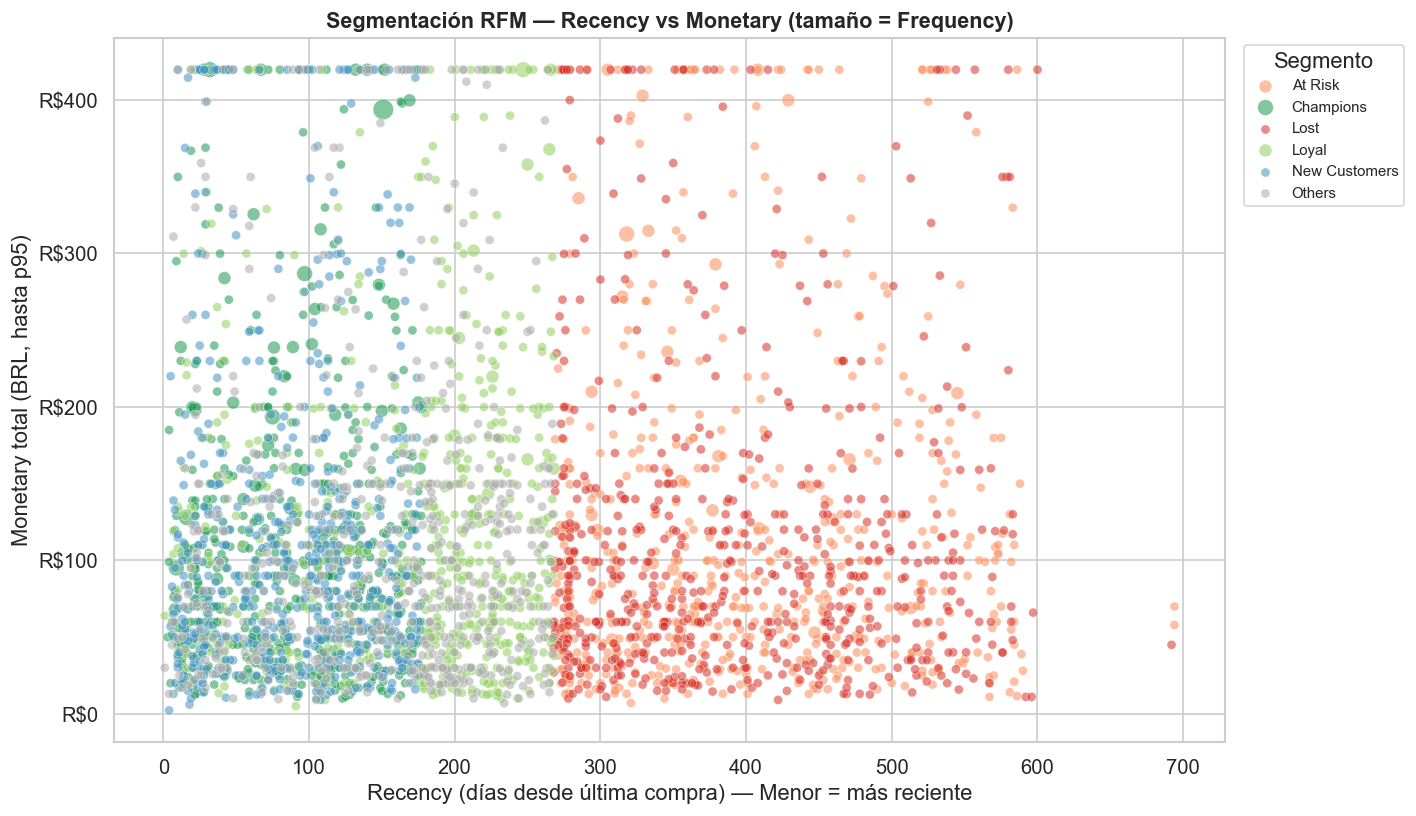

In [7]:
# Paleta de colores por segmento
SEG_COLORS = {
    "Champions":     "#1a9850",
    "Loyal":         "#91cf60",
    "New Customers": "#4393c3",
    "At Risk":       "#fc8d59",
    "Lost":          "#d73027",
    "Others":        "#aaaaaa",
}

# Muestra estratificada para no saturar el gráfico
sample_per_seg = rfm.groupby("segment", group_keys=False).apply(
    lambda g: g.sample(min(len(g), 600), random_state=42)
)

# Clippeamos monetary en p95 para visualización
p95_m = rfm["monetary"].quantile(0.95)
sample_plot = sample_per_seg.copy()
sample_plot["monetary_clipped"] = sample_plot["monetary"].clip(upper=p95_m)

fig, ax = plt.subplots(figsize=(12, 7))

for seg, grp in sample_plot.groupby("segment"):
    ax.scatter(
        grp["recency"],
        grp["monetary_clipped"],
        s=grp["frequency"] * 30,        # tamaño proporcional a frecuencia
        c=SEG_COLORS.get(seg, "gray"),
        alpha=0.55, edgecolors="white", linewidths=0.4,
        label=seg, rasterized=True,
    )

ax.set_title("Segmentación RFM — Recency vs Monetary (tamaño = Frequency)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Recency (días desde última compra) — Menor = más reciente")
ax.set_ylabel("Monetary total (BRL, hasta p95)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax.legend(title="Segmento", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(DASH / "rfm_scatter.png", bbox_inches="tight")
plt.show()

### 6.2 Distribución de clientes y revenue por segmento (barras duales)
Compara el peso de cada segmento en número de clientes vs en revenue generado.  
Si Champions son pocos pero generan mucho revenue, son prioritarios para retención.

C:\Users\pardo\AppData\Local\Temp\ipykernel_48660\1863969302.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(seg_order, rotation=15, ha="right")
C:\Users\pardo\AppData\Local\Temp\ipykernel_48660\1863969302.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(seg_order, rotation=15, ha="right")


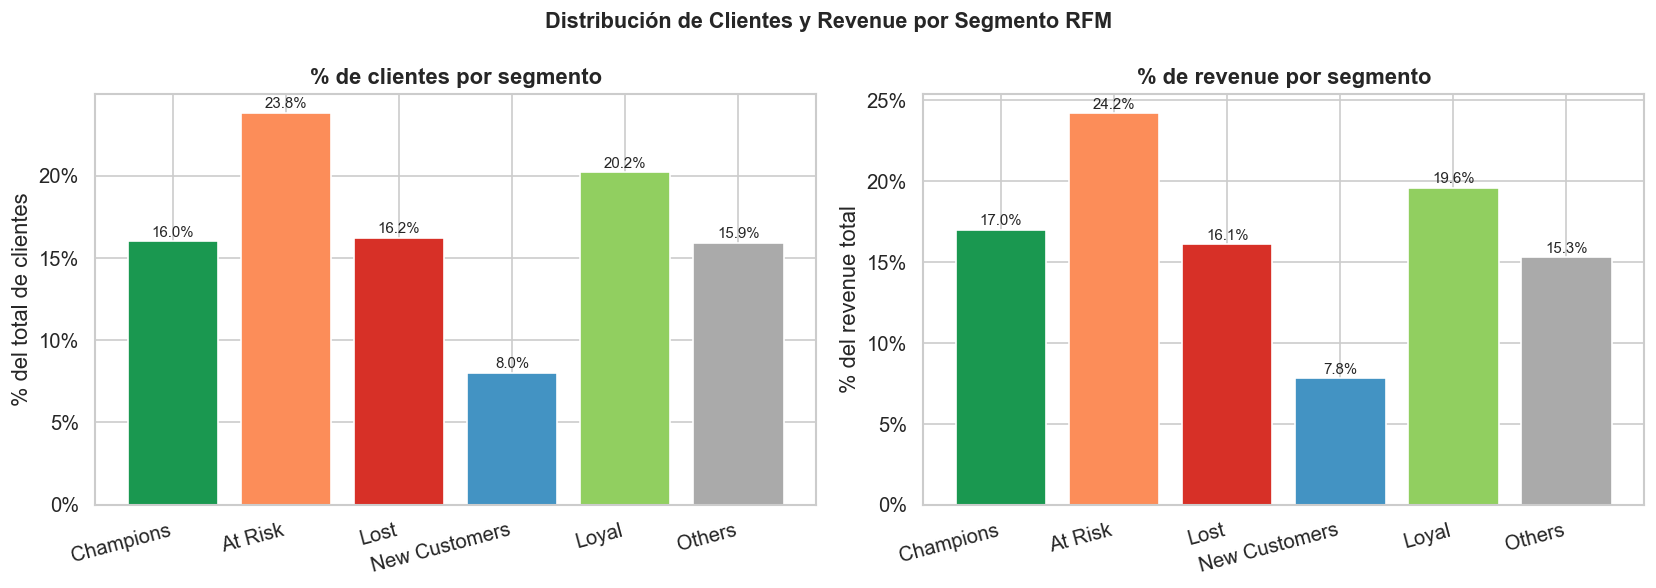

In [8]:
seg_order = seg_summary.sort_values("avg_monetary", ascending=False)["segment"].tolist()
seg_display = seg_summary.set_index("segment").loc[seg_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- % clientes --
colors_bar = [SEG_COLORS.get(s, "gray") for s in seg_order]
axes[0].bar(seg_order, seg_display["pct_customers"], color=colors_bar, edgecolor="white")
for i, (seg, row) in enumerate(seg_display.iterrows()):
    axes[0].text(i, row["pct_customers"] + 0.3, f"{row['pct_customers']:.1f}%",
                 ha="center", fontsize=9)
axes[0].set_title("% de clientes por segmento", fontweight="bold")
axes[0].set_ylabel("% del total de clientes")
axes[0].set_xticklabels(seg_order, rotation=15, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# -- % revenue --
axes[1].bar(seg_order, seg_display["pct_revenue"], color=colors_bar, edgecolor="white")
for i, (seg, row) in enumerate(seg_display.iterrows()):
    axes[1].text(i, row["pct_revenue"] + 0.3, f"{row['pct_revenue']:.1f}%",
                 ha="center", fontsize=9)
axes[1].set_title("% de revenue por segmento", fontweight="bold")
axes[1].set_ylabel("% del revenue total")
axes[1].set_xticklabels(seg_order, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("Distribución de Clientes y Revenue por Segmento RFM",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "rfm_distribution.png", bbox_inches="tight")
plt.show()

### 6.3 Heatmap de scores medios por segmento
Muestra el perfil promedio de R, F y M para cada segmento.  
Valida que la segmentación tiene coherencia: Champions debe tener los tres scores altos.

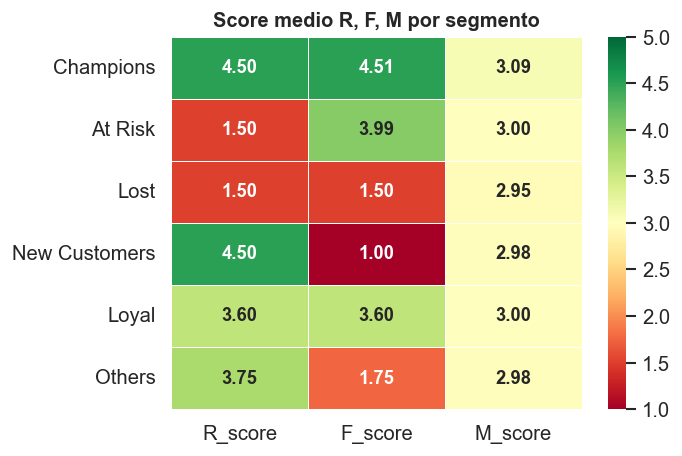

Scores medios por segmento:


,R_score,F_score,M_score
segment,,,
Champions,4.50,4.51,3.09
At Risk,1.50,3.99,3.00
Lost,1.50,1.50,2.95
New Customers,4.50,1.00,2.98
Loyal,3.60,3.60,3.00
Others,3.75,1.75,2.98


In [9]:
score_heatmap = (
    rfm.groupby("segment")[["R_score", "F_score", "M_score"]]
    .mean()
    .round(2)
    .loc[seg_order]  # orden por valor monetario descendente
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    score_heatmap,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=1, vmax=5,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 11, "weight": "bold"},
)
ax.set_title("Score medio R, F, M por segmento", fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(DASH / "rfm_heatmap_segments.png", bbox_inches="tight")
plt.show()

print("Scores medios por segmento:")
display(score_heatmap)

### 6.4 Distribución de Recency y Monetary por segmento (violin plots)

C:\Users\pardo\AppData\Local\Temp\ipykernel_48660\1870607307.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\pardo\AppData\Local\Temp\ipykernel_48660\1870607307.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(seg_violin_order, rotation=15, ha="right")
C:\Users\pardo\AppData\Local\Temp\ipykernel_48660\1870607307.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\pardo\AppData\Local\Temp\ipykernel_48660\1870607307.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(seg_violin_order, rotation=15, ha="right")


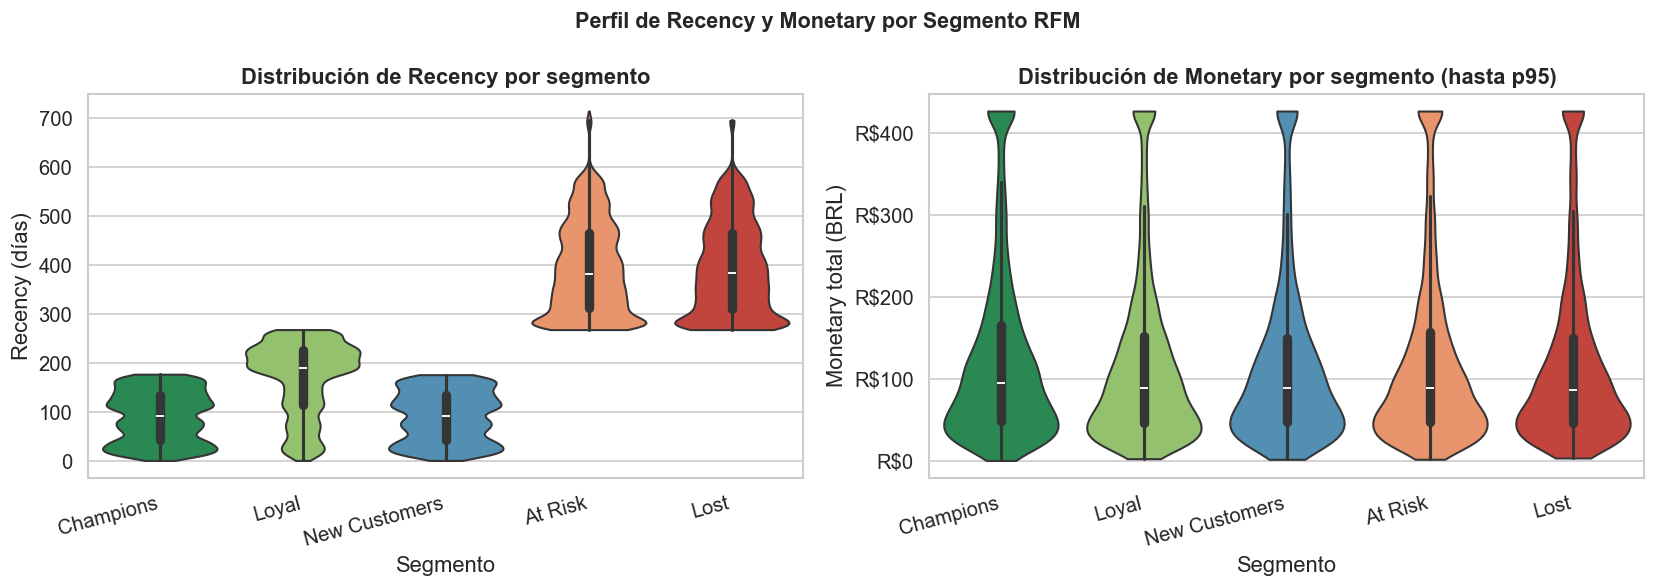

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orden para violines: de mejor a peor segmento
rfm_plot = rfm[rfm["segment"] != "Others"].copy()
rfm_plot["monetary_clipped"] = rfm_plot["monetary"].clip(upper=rfm_plot["monetary"].quantile(0.95))

seg_palette = {s: SEG_COLORS[s] for s in SEG_COLORS if s != "Others"}
seg_violin_order = ["Champions", "Loyal", "New Customers", "At Risk", "Lost"]

sns.violinplot(
    data=rfm_plot, x="segment", y="recency",
    order=seg_violin_order, palette=seg_palette,
    ax=axes[0], inner="box", cut=0,
)
axes[0].set_title("Distribución de Recency por segmento", fontweight="bold")
axes[0].set_xlabel("Segmento")
axes[0].set_ylabel("Recency (días)")
axes[0].set_xticklabels(seg_violin_order, rotation=15, ha="right")

sns.violinplot(
    data=rfm_plot, x="segment", y="monetary_clipped",
    order=seg_violin_order, palette=seg_palette,
    ax=axes[1], inner="box", cut=0,
)
axes[1].set_title("Distribución de Monetary por segmento (hasta p95)", fontweight="bold")
axes[1].set_xlabel("Segmento")
axes[1].set_ylabel("Monetary total (BRL)")
axes[1].set_xticklabels(seg_violin_order, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

plt.suptitle("Perfil de Recency y Monetary por Segmento RFM",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "rfm_violin.png", bbox_inches="tight")
plt.show()

---
## 7. Exportar tabla RFM completa
Guardamos la tabla RFM con scores y segmentos para uso en el notebook de evaluación.

In [11]:
rfm_out = ROOT / "data" / "olist_rfm.csv"
rfm.to_csv(rfm_out, index=False)

size_mb = rfm_out.stat().st_size / 1024 / 1024
print(f"Exportado: {rfm_out}")
print(f"Tamaño:    {size_mb:.2f} MB")
print(f"Filas:     {len(rfm):,}")
print(f"Columnas:  {list(rfm.columns)}")

Exportado: C:\Users\pardo\Documents\portfolio\proyecto 1\data\olist_rfm.csv
Tamaño:    6.05 MB
Filas:     93,337
Columnas:  ['customer_unique_id', 'frequency', 'monetary', 'recency', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_string', 'segment']


---
## 8. Resumen ejecutivo — Segmentación RFM

### Hallazgos clave

In [12]:
champs  = seg_summary[seg_summary["segment"] == "Champions"].iloc[0] if "Champions" in seg_summary["segment"].values else None
lost    = seg_summary[seg_summary["segment"] == "Lost"].iloc[0]      if "Lost"       in seg_summary["segment"].values else None
at_risk = seg_summary[seg_summary["segment"] == "At Risk"].iloc[0]   if "At Risk"    in seg_summary["segment"].values else None
new_c   = seg_summary[seg_summary["segment"] == "New Customers"].iloc[0] if "New Customers" in seg_summary["segment"].values else None

print("=" * 65)
print("RESUMEN EJECUTIVO — SEGMENTACIÓN RFM")
print("=" * 65)
print(f"\nTotal clientes analizados: {len(rfm):,}")
print(f"\n{'Segmento':<16} {'Clientes':>9} {'% clientes':>11} {'% revenue':>10} {'Avg monetary':>13}")
print("-" * 65)
for _, row in seg_summary.iterrows():
    print(f"{row['segment']:<16} {int(row['n_customers']):>9,} {row['pct_customers']:>10.1f}% {row['pct_revenue']:>9.1f}% {row['avg_monetary']:>12.0f} BRL")

print("\n" + "=" * 65)
print("ACCIONES RECOMENDADAS POR SEGMENTO")
print("=" * 65)
actions = {
    "Champions":     "Programa de fidelización VIP, early access a nuevos productos, referidos",
    "Loyal":         "Upsell a categorías premium, descuentos por volumen, encuestas NPS",
    "New Customers": "Onboarding email sequence, descuento en segundo pedido, recomendaciones",
    "At Risk":       "Campaña de reactivación urgente: cupón con fecha límite, email win-back",
    "Lost":          "Campaña de reactivación de bajo coste o baja de lista de marketing",
    "Others":        "Monitoreo continuo; clasificar en próxima iteración RFM",
}
for seg, action in actions.items():
    count = seg_counts.get(seg, 0)
    print(f"\n[{seg}] ({count:,} clientes)")
    print(f"  → {action}")

RESUMEN EJECUTIVO — SEGMENTACIÓN RFM

Total clientes analizados: 93,337

Segmento          Clientes  % clientes  % revenue  Avg monetary
-----------------------------------------------------------------
Champions           14,950       16.0%      17.0%          151 BRL
At Risk             22,233       23.8%      24.2%          144 BRL
Lost                15,102       16.2%      16.1%          141 BRL
New Customers        7,426        8.0%       7.8%          139 BRL
Loyal               18,819       20.2%      19.6%          138 BRL
Others              14,807       15.9%      15.3%          136 BRL

ACCIONES RECOMENDADAS POR SEGMENTO

[Champions] (14,950 clientes)
  → Programa de fidelización VIP, early access a nuevos productos, referidos

[Loyal] (18,819 clientes)
  → Upsell a categorías premium, descuentos por volumen, encuestas NPS

[New Customers] (7,426 clientes)
  → Onboarding email sequence, descuento en segundo pedido, recomendaciones

[At Risk] (22,233 clientes)
  → Campaña de

---
## 9. Resumen metodológico

| Paso | Decisión | Motivo |
|------|----------|--------|
| Fecha de referencia | `max_date + 1 día` | Simula el punto de análisis al cierre del dataset |
| Escala de scoring | Quintiles 1–5 | Robusta ante distribuciones sesgadas y outliers |
| Desempate de quintiles | `rank(method='first')` | Evita errores con distribuciones muy concentradas (F=1 dominante) |
| Segmentación | Reglas basadas en R y F | F es el driver de lealtad más accionable para CRM |
| Categoría `Others` | Segmento residual | Combinaciones intermedias no accionables directamente |

### Próximos pasos — Fase 5 (Evaluation)
- Cruzar segmentos RFM con `is_negative_review` para identificar si clientes `At Risk` o `Lost` tienen mayor tasa de reseñas negativas
- Modelo predictivo supervisado de `is_negative_review` usando `delivery_delay_days`, `freight_ratio` y `delivery_days`
- Dashboard final consolidando hallazgos de todas las fases